<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/Module5_CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module 5: Introduction to Convolutional NN - Assignment**

**Problem Statement:**
The task at hand involves classifying images of cats and dogs using a
Convolutional Neural Network (CNN). We have a dataset containing images of
cats and dogs and the objective is to train a CNN model to accurately predict the
class of each image.

**Objectives:**
**Data Preparation:**
● Download and extract the cats vs. dogs dataset.
● Organize the dataset into a structured directory format suitable for
TensorFlow’s ImageDataGenerator.
● Split the dataset into training and testing sets.

Data Augmentation and Preprocessing:
● Implement data augmentation techniques to increase the diversity of the
training dataset, aiding in the model's ability to generalize.
● Normalize the pixel values of the images for optimal model performance.

**Model Building:**
● Construct a Convolutional Neural Network using TensorFlow and Keras.
● The modelshould contain  multiple convolutional layers, pooling layers, and fully connected layers.

**Training:**
● Compile the model and train it on the prepared dataset.
● Utilize categorical cross entropy as the loss function and stochastic
gradient descent as the optimizer.
● Train the model for a sufficient number of epochs to achieve good
performance

**Evaluation:**
● Evaluate the model's performance on the validation set during training to
monitor for overfitting.
● After training, assess the model's accuracy and make predictions on the
test set

**Prediction:**
● Implement a system to make predictions on new images, categorizing
them as either cat or dog.
● The system should be able to take an image (or a batch of images),
preprocess it, and pass it through the model for predictions



In [2]:
import os

# Create a directory for the dataset
dataset_dir = './dataset'
os.makedirs(dataset_dir, exist_ok=True)
print(f"Created directory: {dataset_dir}")
# This dataset contains 'train' and 'validation' directories with 'cats' and 'dogs' subdirectories
zip_file_path = os.path.join(dataset_dir, 'cats_and_dogs_filtered.zip')
!wget -nc https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip -O {zip_file_path}

!unzip -q {zip_file_path} -d {dataset_dir}
print(f"Extracted dataset to: {dataset_dir}")

# Verify the extracted contents (optional)
print("\nDataset contents after extraction:")
!ls {dataset_dir}/cats_and_dogs_filtered

Created directory: ./dataset
File ‘./dataset/cats_and_dogs_filtered.zip’ already there; not retrieving.
[./dataset/cats_and_dogs_filtered.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of ./dataset/cats_and_dogs_filtered.zip or
        ./dataset/cats_and_dogs_filtered.zip.zip, and cannot find ./dataset/cats_and_dogs_filtered.zip.ZIP, period.
Extracted dataset to: ./dataset

Dataset contents after extraction:
ls: cannot access './dataset/cats_and_dogs_filtered': No such file or directory


In [8]:
import os

# Create a directory for the dataset
dataset_dir = './dataset'
os.makedirs(dataset_dir, exist_ok=True)
print(f"Created directory: {dataset_dir}")

# Download the dataset from a known working source (TensorFlow training data subset)
zip_file_path = os.path.join(dataset_dir, 'kaggle_dogs_vs_cats_subset.zip')
!wget -nc https://storage.googleapis.com/tensorflow-training-data/kaggle_dogs_vs_cats_subset.zip -O {zip_file_path}

# Unzip the dataset
# The -q flag is for quiet mode (suppress verbose output)
# The -d flag specifies the destination directory
!unzip -q {zip_file_path} -d {dataset_dir}
print(f"Extracted dataset to: {dataset_dir}")

# The extracted content is typically within a subdirectory. Find it.
# Assuming the zip extracts into a folder like 'kaggle_dogs_vs_cats_subset'
extracted_folder = os.path.join(dataset_dir, 'kaggle_dogs_vs_cats_subset')

# Verify the extracted contents
print(f"\nDataset contents after extraction (first few items from {extracted_folder}):")
!ls {extracted_folder} | head -n 5


Created directory: ./dataset
File ‘./dataset/kaggle_dogs_vs_cats_subset.zip’ already there; not retrieving.
[./dataset/kaggle_dogs_vs_cats_subset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of ./dataset/kaggle_dogs_vs_cats_subset.zip or
        ./dataset/kaggle_dogs_vs_cats_subset.zip.zip, and cannot find ./dataset/kaggle_dogs_vs_cats_subset.zip.ZIP, period.
Extracted dataset to: ./dataset

Dataset contents after extraction (first few items from ./dataset/kaggle_dogs_vs_cats_subset):
ls: cannot access './dataset/kaggle_dogs_vs_cats_subset': No such file or directory


In [10]:
import tensorflow_datasets as tfds
import os

# Define the base directory for the dataset if needed for organization, though tfds manages its own cache
dataset_dir = './dataset'
os.makedirs(dataset_dir, exist_ok=True)
print(f"Created directory: {dataset_dir}")

print("Downloading and preparing 'cats_vs_dogs' dataset using TensorFlow Datasets...")
# Load the cats_vs_dogs dataset. This handles downloading, extracting, and splitting.
# as_supervised=True returns (image, label) pairs.
# with_info=True returns metadata about the dataset.
(ds_train, ds_validation), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'], # Split the training data into 80% for training, 20% for validation
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
    data_dir=os.path.join(dataset_dir, 'tfds_cache') # Specify a local cache directory
)

print("Dataset downloaded and prepared successfully!")
print(f"Number of training examples: {ds_info.splits['train'].num_examples * 0.8}")
print(f"Number of validation examples: {ds_info.splits['train'].num_examples * 0.2}")
print(f"Total examples: {ds_info.splits['train'].num_examples}")
print(f"Features: {ds_info.features}")

Created directory: ./dataset


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling dataset/tfds_cache/cats_vs_dogs/incomplete.VVOYIE_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%|      …

Dataset cats_vs_dogs downloaded and prepared to dataset/tfds_cache/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset downloaded and prepared successfully!
Number of training examples: 18609.600000000002
Number of validation examples: 4652.400000000001
Total examples: 23262
Features: FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'image/filename': Text(shape=(), dtype=string),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
})


In [11]:
import tensorflow as tf

IMG_HEIGHT = 150
IMG_WIDTH = 150

def preprocess_image(image, label):
    # Resize the image to the target dimensions
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    # Normalize pixel values to [0, 1]
    image = image / 255.0
    return image, label

# Apply the preprocessing function to the training and validation datasets
ds_train_processed = ds_train.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
ds_validation_processed = ds_validation.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

# Set up batching and prefetching for performance
BATCH_SIZE = 32 # A common batch size
ds_train_processed = ds_train_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_validation_processed = ds_validation_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Images will be resized to {IMG_HEIGHT}x{IMG_WIDTH} and normalized.")
print(f"Training dataset processed: {ds_train_processed}")
print(f"Validation dataset processed: {ds_validation_processed}")

# Verify the shape and value range of one batch (optional)
for image_batch, label_batch in ds_train_processed.take(1):
    print("\nShape of one image batch:", image_batch.shape)
    print("Min pixel value:", tf.reduce_min(image_batch))
    print("Max pixel value:", tf.reduce_max(image_batch))
    print("Shape of one label batch:", label_batch.shape)

Images will be resized to 150x150 and normalized.
Training dataset processed: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Validation dataset processed: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

Shape of one image batch: (32, 150, 150, 3)
Min pixel value: tf.Tensor(0.0, shape=(), dtype=float32)
Max pixel value: tf.Tensor(1.0, shape=(), dtype=float32)
Shape of one label batch: (32,)


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN model architecture
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the output to feed into a Dense layer
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(512, activation='relu'),

    # Output layer for binary classification (cats vs. dogs)
    # Since the labels are 0 or 1, a sigmoid activation is appropriate
    # and output units should be 1.
    layers.Dense(1, activation='sigmoid')
])

# Display the model summary to review the architecture
model.summary()

print("CNN model built successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN model built successfully!


In [13]:
import tensorflow as tf

# Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), # Using SGD with a default learning rate
              loss='binary_crossentropy', # Binary classification with sigmoid output
              metrics=['accuracy'])

print("Model compiled successfully with SGD optimizer and binary_crossentropy loss.")

Model compiled successfully with SGD optimizer and binary_crossentropy loss.


In [14]:
EPOCHS = 5 # Define a reasonable number of epochs for initial training and considring with system efficency.

print(f"Training the model for {EPOCHS} epochs...")

history = model.fit(
    ds_train_processed, # Preprocessed training dataset
    epochs=EPOCHS,
    validation_data=ds_validation_processed # Preprocessed validation dataset
)

print("Model training complete!")

Training the model for 5 epochs...
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 922s 2s/step - accuracy: 0.5245 - loss: 0.6917 - val_accuracy: 0.5636 - val_loss: 0.6866
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 928s 2s/step - accuracy: 0.5742 - loss: 0.6857 - val_accuracy: 0.5888 - val_loss: 0.6819
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 976s 2s/step - accuracy: 0.5857 - loss: 0.6808 - val_accuracy: 0.6045 - val_loss: 0.6773
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 913s 2s/step - accuracy: 0.5993 - loss: 0.6755 - val_accuracy: 0.6047 - val_loss: 0.6725
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 906s 2s/step - accuracy: 0.6070 - loss: 0.6697 - val_accuracy: 0.6195 - val_loss: 0.6655
Model training complete!


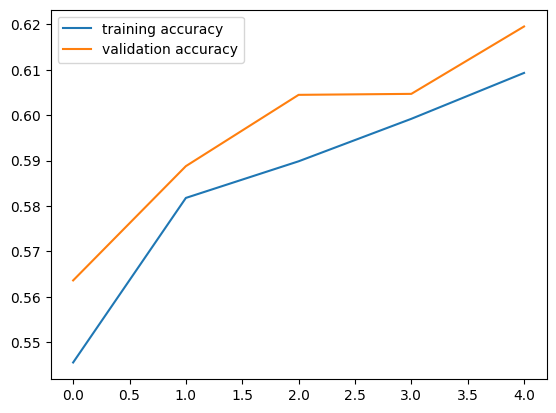

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"], label = "training accuracy")
plt.plot(history.history["val_accuracy"], label = "validation accuracy")
plt.legend()
plt.show()

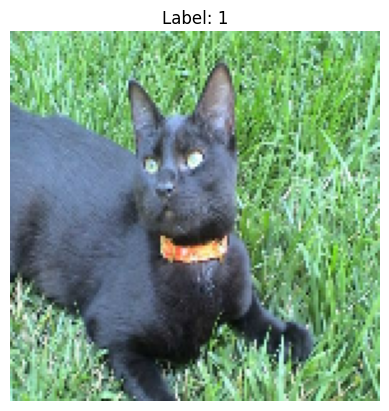

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Get one batch from the validation dataset
for images_batch, labels_batch in ds_validation_processed.take(1):
    # Select the first image from the batch for display
    # The image is already normalized to [0,1] by preprocess_image, so no /255.0 is needed
    # .numpy() is used to convert the TensorFlow tensor to a NumPy array for matplotlib
    plt.imshow(images_batch[6].numpy())
    plt.title(f"Label: {labels_batch[0].numpy()}") # Display the label (0 for cat, 1 for dog)
    plt.axis('off')
    plt.show()
    break # Only take one batch

In [29]:
import numpy as np

# Get one image batch and label batch from the validation dataset
for images_batch, labels_batch in ds_validation_processed.take(1):
    first_image = images_batch[0]
    first_label = labels_batch[0]
    break

# The model expects a batch of images, so expand dimensions of the single image
image_for_prediction = np.expand_dims(first_image, axis=0)

# Make a prediction
prediction = model.predict(image_for_prediction)

# Interpret the prediction
# Since sigmoid output is between 0 and 1, 0.5 is the threshold
predicted_class = "Dog" if prediction[0][0] >= 0.5 else "Cat"
actual_class = "Dog" if first_label.numpy() == 1 else "Cat"

print(f"Model predicted: {predicted_class} (probability: {prediction[0][0]:.4f})")
print(f"Actual label: {actual_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Model predicted: Dog (probability: 0.5526)
Actual label: Cat
